# Tier 1 位置推定手法 — 解説とフル再計算

**対象手法**: `wknn` / `studentt_fp` / `gp_corridor`（改善手法ノート Tier 1）

このノートは自己完結型です。**Run All（全セル実行）で Protocol A / LOLO の全評価が
その場で走り**、凍結済み結果 `results/protocol_a.csv`・`results/lolo_summary.csv` と
数値照合します（§7）。

- 実装はノート内に複製しません。すべて `icsr8` パッケージの公開関数
  （`icsr8.harness.run_protocol_a` / `run_lolo`、`icsr8.methods.run_method` /
  `REGISTRY`）を呼びます。
- 乱数・bootstrap は `icsr8.constants.RANDOM_SEED = 0`、`B = 1000` で本番 CSV と同一条件。
- 図はインライン表示のみ。`results/`・`doc/` へは一切書き込みません。

## 1. 概要 — Tier 1 の位置づけと 3 手法

改善手法ノート（`doc/improvement_methods_note.txt`）は Tier 1 を「2m 未満達成の本命」と
位置づける。ベースライン WCL（重心加重）は **推定位置が選択 AP の凸包内に拘束される**
という根本的限界を持ち、L 字廊下の角部で 12m 超の誤差を出す。Tier 1 の 3 手法はいずれも
この凸包制約から解放される設計になっている。

### 1.1 `wknn` — Weighted K-Nearest-Neighbor Fingerprinting（手法1）

RSSI ベクトル全体を fingerprint とし、既知参照点との類似度で位置推定する。

$$ \hat{T} = \frac{\sum_{j} w_j\, P_j}{\sum_{j} w_j}, \qquad
   w_j = \frac{1}{d_j^{\,p}}, \qquad
   d_j = \lVert r_\text{query} - r_j \rVert_2 $$

- **特徴空間**: 学習データの $(ap\_name, band)$ 鍵の和集合で固定。非検出は
  `NON_DETECT_DBM = -100 dBm` で埋める。
- **設計判断（docstring より）**: AP 座標に依存しないため凸包制約がなく、座標未知の
  他階 AP も特徴量として使える。角部は C2 棟 AP の出現パターンが特徴的で fingerprint
  matching が効く。
- **ハイパーパラメータ**: $K \in \{1,3,5,7\}$、weighting $\in$ {uniform, inv($1/d$),
  inv\_sq($1/d^2$)} を location 単位 5-fold inner CV でグリッド選択。タイブレークは
  $K$ 小優先 → uniform < inv < inv\_sq。

### 1.2 `studentt_fp` — 確率的 Fingerprinting（手法2 + 手法4 + 手法11）

RSSI を Student-t（外れ値に頑健）、AP 検出/非検出を Bernoulli でモデル化し、
posterior 平均で座標推定する。

$$ \log p(l\,|\,q) = \sum_k \Big[ D_k \log \hat{q}_{l,k}
   + \beta_k\,\mathbf{1}[k\in R]\,\log t_\nu(r_k;\,\mu_{l,k}+\hat\delta,\ \sigma_{l,k})
   + (1-D_k)\log(1-\hat{q}_{l,k}) \Big] $$

- $\hat{q}_{l,k} = (n_\text{detect}+1)/(10+2)$ … Beta(1,1) 平滑化。未検出鍵は $1/12$（手法2）。
- $\hat\delta = \mathrm{median}_{k\in R}(r_k - \mu_{l,k})$ … 端末 AGC・身体遮蔽等の
  scan 全体オフセット除去（**手法4**）。
- $\beta_k = 1/(1+(\bar\sigma_k/\sigma_\text{ref})^2)$ … 分散の大きい鍵を下方重み付けする
  信頼度（**手法11**）。t 項のみに適用（Bernoulli 項には掛けない、docstring 参照）。
- t 項は $n_\text{detect}\ge$ `MIN_COUNT`(=3) の eligible 鍵のみ。
- **設計判断**: 座標は posterior 平均（Why not MAP: MAP は 2m グリッドへ量子化される）。
  $\nu \in \{3,5,10\}$ を inner CV の pooled L2 argmin で選択。

### 1.3 `gp_corridor` — 廊下座標系 GP Radio Map + 階層推定（手法3 + 手法16）

各 $(ap\_name, band)$ 鍵の RSSI を廊下弧長 $s$ の関数として Matérn-3/2 GP でモデル化する。
**Euclidean ではなく廊下 geodesic（弧長差）** を距離に使うのが要点（壁越しの疑似相関回避）。

$$ k(d) = \sigma_f^2\,\Big(1+\tfrac{\sqrt3\,d}{\ell}\Big)\exp\!\Big(-\tfrac{\sqrt3\,d}{\ell}\Big),
   \qquad d = |s - s'| $$

推定は 2 段構成（**手法16: segment-first, coordinate-second**）:

1. **セグメント分類**: WKNN 特徴行列 → ロジスティック回帰で廊下セグメント（C/C2/C3）を分類。
2. **1D 座標推定**: そのセグメント範囲内の $s$ グリッド上で GP 尤度の softmax posterior 平均。

$$ \log p(s\,|\,r) = -\tfrac{1}{2}\sum_{a,b}\Big[\frac{(r-\mu(s))^2}{v(s)+\sigma_n^2}
   + \log\big(v(s)+\sigma_n^2\big)\Big] $$

- **設計判断**: セグメント段を挟むことで L 字コーナーでの posterior 質量分裂
  （2D 平均が廊下外へ出る問題）を防ぐ。GP のハイパーパラメータは log marginal
  likelihood 最大で鍵ごとに選択。

In [1]:
# --- matplotlib backend を最優先で inline に固定 -------------------------
# Why: icsr8.harness は import 時に MPLBACKEND=Agg を setdefault する。pyplot を
# load する前に inline を宣言しておかないと図がセルに埋め込まれない。
%matplotlib inline
import os
os.environ["MPLBACKEND"] = "module://matplotlib_inline.backend_inline"

import time, sys, platform
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("matplotlib backend:", matplotlib.get_backend())
assert "inline" in matplotlib.get_backend(), "inline backend が有効でない"

TIMINGS = {}  # 重い計算セルの経過秒を蓄積（§8 で表示）

matplotlib backend: inline


## 2. データ読み込み

`data/` はリポジトリルート直下。ノートの実行 cwd に依らず `data/dataset` を含む祖先
ディレクトリを自動探索して解決する（`os.chdir` は使わない）。本番 CSV は C3F データ
（`data/dataset`・`data/rawdata`）で生成されているため、C4F の `*_r0701` は使わない。

In [2]:
from icsr8.io import load_ap_coords, load_location_coords, load_raw_scans
from icsr8.constants import RANDOM_SEED

# data/dataset を含む祖先を探す（cwd が repo root でも notebooks/ でも解決可能）
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data" / "dataset").exists())
DATA = ROOT / "data"
print("ROOT =", ROOT)

ap13  = load_ap_coords(DATA / "dataset" / "AP_coordinate_C3F.csv")
truth = load_location_coords(DATA / "dataset" / "location_coordinate_C.csv")[["location_p", "x", "y"]]
scans_f = load_raw_scans("forward",  DATA / "rawdata")   # 往路 59 地点
scans_b = load_raw_scans("backward", DATA / "rawdata")   # 復路 59 地点

B = 1000  # bootstrap 反復数（本番と同一）
SEED = RANDOM_SEED
print(f"RANDOM_SEED={SEED}  B={B}")
print(f"ap13: {ap13.shape}  truth: {truth.shape} 地点")
print(f"forward scans: {scans_f.shape[0]} 行 / {scans_f['location_p'].nunique()} 地点")
print(f"backward scans: {scans_b.shape[0]} 行 / {scans_b['location_p'].nunique()} 地点")
truth.head()

ROOT = /Users/kinoko/Development/github/icsR8
RANDOM_SEED=0  B=1000
ap13: (13, 5)  truth: (59, 3) 地点
forward scans: 16659 行 / 59 地点
backward scans: 17432 行 / 59 地点


,location_p,x,y
0,1,32,0
1,2,30,0
2,3,28,0
3,4,26,0
4,5,24,0


## 3. 各手法のデモ（1 地点の推定過程の可視化）

Protocol A の前向き fold（train=往路 全 59 地点、test=復路）を素材に、各手法が 1 地点を
どう推定するかを覗く。デモは公開レジストリ `REGISTRY` でインスタンスを組み、学習済み属性
（`wknn` の DB 行列、`gp_corridor` の GP、`studentt_fp` の posterior）を借りて描画する。
`scripts/dump_method_diagnostics.py` と同じ流儀。

In [3]:
from icsr8.methods import REGISTRY
from icsr8.corridor import xy_to_arclength, arclength_to_xy
from icsr8.constants import CORRIDOR_SEGMENTS

# デモ対象地点: L 字コーナー (0,0) に最も近い地点（WCL が苦手な角部）
truth_xy = truth.set_index("location_p")[["x", "y"]]
corner_loc = int(((truth_xy["x"]**2 + truth_xy["y"]**2)).idxmin())
print("デモ対象 location_p =", corner_loc, "truth =", tuple(truth_xy.loc[corner_loc].round(2)))

def corridor_polyline():
    xs, ys = [CORRIDOR_SEGMENTS[0][0][0]], [CORRIDOR_SEGMENTS[0][0][1]]
    for (_, _), (bx, by) in CORRIDOR_SEGMENTS:
        xs.append(bx); ys.append(by)
    return xs, ys

デモ対象 location_p = 17 truth = (0, 0)


### 3.1 `wknn` — 近傍と重み

学習済み DB 行列とクエリ特徴ベクトルの L2 距離から上位 $K$ 近傍を取り、重み付き重心を作る。
下の散布図は廊下折れ線・全 DB 地点・選ばれた近傍（サイズ=重み）・推定点・真値を示す。

選択ハイパーパラメータ: K=5, weighting='inv_sq'
推定 = (1.54, 0.47)  真値 = (0.00, 0.00)  誤差 = 1.62 m

上位近傍:
 db_x  db_y  RSSI_dist  weight
  0.0   0.0     49.417   0.351
  0.0   2.0     60.189   0.237
  2.0   0.0     72.638   0.163
  4.0   0.0     79.074   0.137
  6.0   0.0     87.628   0.112


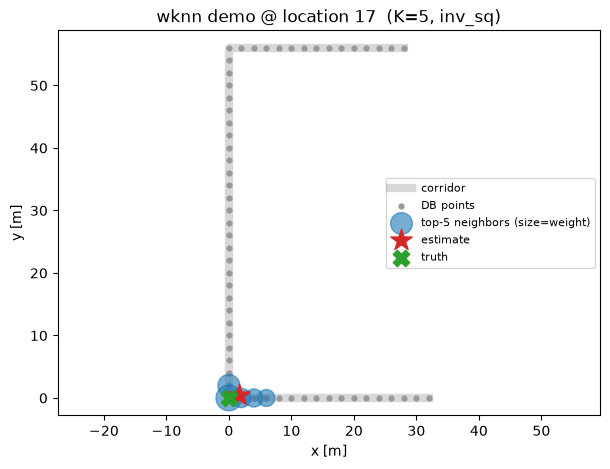

In [4]:
from icsr8.methods.wknn import _build_matrix as wknn_build, _weighted_centroid

wk = REGISTRY["wknn"]().fit(scans_f, ap13, truth)
print(f"選択ハイパーパラメータ: K={wk.selected_k}, weighting={wk.selected_weighting!r}")

# クエリ地点（復路）の特徴ベクトルを学習鍵空間へ整列
q_scans = scans_b[scans_b["location_p"] == corner_loc]
_, q_locs, q_mat = wknn_build(q_scans, keys=wk._keys)
qvec = q_mat[q_locs.index(corner_loc)]
dist = np.linalg.norm(wk._db_matrix - qvec, axis=1)

order = np.argsort(dist, kind="stable")[:wk.selected_k]
if wk.selected_weighting == "uniform":
    w = np.ones(wk.selected_k)
elif wk.selected_weighting == "inv":
    w = 1.0 / (dist[order] + 1e-9)
else:
    w = 1.0 / (dist[order]**2 + 1e-9)
est_x, est_y = _weighted_centroid(dist, wk._db_xy, wk.selected_k, wk.selected_weighting)
tx, ty = truth_xy.loc[corner_loc]
print(f"推定 = ({est_x:.2f}, {est_y:.2f})  真値 = ({tx:.2f}, {ty:.2f})  "
      f"誤差 = {np.hypot(est_x-tx, est_y-ty):.2f} m")

nb = pd.DataFrame({
    "db_x": wk._db_xy[order, 0], "db_y": wk._db_xy[order, 1],
    "RSSI_dist": dist[order], "weight": w / w.sum(),
})
print("\n上位近傍:"); print(nb.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
cx, cy = corridor_polyline()
ax.plot(cx, cy, "-", color="0.7", lw=6, alpha=0.5, label="corridor", zorder=0)
ax.scatter(wk._db_xy[:, 0], wk._db_xy[:, 1], s=12, color="0.6", label="DB points")
ax.scatter(nb["db_x"], nb["db_y"], s=60 + 800*nb["weight"], color="tab:blue",
           alpha=0.6, label=f"top-{wk.selected_k} neighbors (size=weight)")
ax.scatter([est_x], [est_y], marker="*", s=260, color="tab:red", label="estimate", zorder=5)
ax.scatter([tx], [ty], marker="X", s=140, color="tab:green", label="truth", zorder=5)
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
ax.set_title(f"wknn demo @ location {corner_loc}  (K={wk.selected_k}, {wk.selected_weighting})")
ax.legend(fontsize=8, loc="best"); ax.set_aspect("equal", adjustable="datalim")
plt.show()

### 3.2 `studentt_fp` — 学習地点上の posterior

クエリ 1 地点に対する全学習地点の posterior $p(l\,|\,q)$ を弧長 $s$ 上に並べる。
座標推定は posterior 平均（MAP ではない）。

選択 nu = 3
推定(posterior平均) = (0.00, 0.00)  MAP 地点 = 17  誤差 = 0.00 m


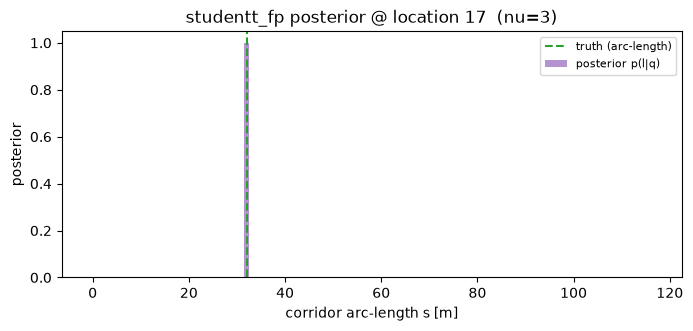

In [5]:
st = REGISTRY["studentt_fp"]().fit(scans_f, ap13, truth)
print(f"選択 nu = {st.selected_nu}")
est_st = st.predict(scans_b[scans_b["location_p"] == corner_loc])

post = st.last_posterior[corner_loc]                 # (n_loc,) 学習地点上の事後
map_loc = st.last_map_locations[corner_loc]
locs = np.array(st._model.locs)
s_locs = np.array([xy_to_arclength(*truth_xy.loc[int(l)]) for l in locs])
s_true = xy_to_arclength(*truth_xy.loc[corner_loc])
ex, ey = est_st.iloc[0]["x"], est_st.iloc[0]["y"]
print(f"推定(posterior平均) = ({ex:.2f}, {ey:.2f})  MAP 地点 = {map_loc}  "
      f"誤差 = {np.hypot(ex-tx, ey-ty):.2f} m")

fig, ax = plt.subplots(figsize=(8, 3.2))
o = np.argsort(s_locs)
ax.bar(s_locs[o], post[o], width=1.2, color="tab:purple", alpha=0.7, label="posterior p(l|q)")
ax.axvline(s_true, color="tab:green", ls="--", label="truth (arc-length)")
ax.set_xlabel("corridor arc-length s [m]"); ax.set_ylabel("posterior")
ax.set_title(f"studentt_fp posterior @ location {corner_loc}  (nu={st.selected_nu})")
ax.legend(fontsize=8); plt.show()

### 3.3 `gp_corridor` — 1 鍵の radio map $\mu(s)\pm2\sigma$

学習済み GP の 1 鍵について、弧長 $s$ 全域の事後平均 $\mu(s)$ と $\pm2\sigma$
（雑音込み）を、学習観測点に重ねて描く。縦の区切りは廊下セグメント境界（C/C2/C3）。

segment_train_accuracy = 1.000  GP 鍵数 = 82
デモ鍵 = ('AP-C2-3F-01', '5G')  観測地点数 = 46


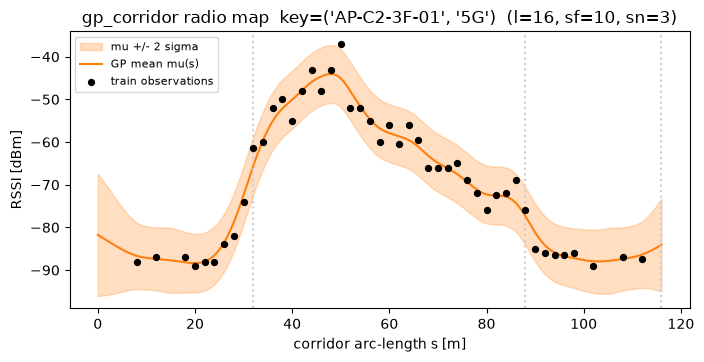

In [6]:
from icsr8.methods.gp_corridor import _gp_posterior, SEGMENT_RANGES
from icsr8.fingerprint import ap_band_fingerprint

gp = REGISTRY["gp_corridor"]().fit(scans_f, ap13, truth)
print(f"segment_train_accuracy = {gp.segment_train_accuracy:.3f}  "
      f"GP 鍵数 = {len(gp.gp_params)}")

# 観測地点数が最多の鍵を選ぶ（一番なめらかに見える例）
ab_f = ap_band_fingerprint(scans_f)
counts = ab_f.groupby(["ap_name", "band"])["location_p"].nunique()
demo_key = max(gp._gps.keys(), key=lambda k: counts.get(k, 0))
print("デモ鍵 =", demo_key, " 観測地点数 =", int(counts[demo_key]))

grp = ab_f[(ab_f["ap_name"] == demo_key[0]) & (ab_f["band"] == demo_key[1])]
s_obs = np.array([xy_to_arclength(*truth_xy.loc[int(l)]) for l in grp["location_p"]])
y_obs = grp["rssi_median"].to_numpy()

s_grid = np.linspace(0, sum(np.hypot(bx-ax_, by-ay_)
                            for (ax_, ay_), (bx, by) in CORRIDOR_SEGMENTS), 400)
mu, v = _gp_posterior(gp._gps[demo_key], s_grid)
sd = np.sqrt(v + gp._gps[demo_key].sigma_n**2)

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.fill_between(s_grid, mu-2*sd, mu+2*sd, color="tab:orange", alpha=0.25, label="mu +/- 2 sigma")
ax.plot(s_grid, mu, color="tab:orange", label="GP mean mu(s)")
ax.scatter(s_obs, y_obs, s=18, color="k", zorder=5, label="train observations")
for name, (lo, hi) in SEGMENT_RANGES.items():
    ax.axvline(hi, color="0.8", ls=":")
ax.set_xlabel("corridor arc-length s [m]"); ax.set_ylabel("RSSI [dBm]")
ax.set_title(f"gp_corridor radio map  key={demo_key}  "
             f"(l={gp.gp_params[demo_key]['length']:.0f}, "
             f"sf={gp.gp_params[demo_key]['sigma_f']:.0f}, "
             f"sn={gp.gp_params[demo_key]['sigma_n']:.0f})")
ax.legend(fontsize=8); plt.show()

## 4. Protocol A（2 fold）フル計算

`icsr8.harness.run_protocol_a` で 3 手法を forward↔backward の 2 fold で評価する。
1 回だけ呼び、結果と誤差台帳を保持する（デモ節で個別に fit したものとは別。ここが本番の
評価経路）。指標は各 fold 内の誤差ベクトルから算出（`seed=0, B=1000`）。

In [7]:
from icsr8.harness import run_protocol_a

METHODS = ["wknn", "studentt_fp", "gp_corridor"]
t0 = time.time()
proto_res, proto_led = run_protocol_a(METHODS, scans_f, scans_b, ap13, truth, seed=SEED, B=B)
TIMINGS["protocol_a"] = time.time() - t0
print(f"Protocol A 経過: {TIMINGS['protocol_a']:.1f} s  失敗行={int(proto_res['failed'].sum())}")

show = ["method", "fold", "ave", "median", "p90", "within_2m", "max", "std"]
disp = proto_res[show].rename(columns={
    "ave": "Ave", "median": "Median", "p90": "p90",
    "within_2m": "<=2m", "max": "Max", "std": "Std"})
disp.round(4)

Protocol A 経過: 1.3 s  失敗行=0


,method,fold,Ave,Median,p90,<=2m,Max,Std
0,wknn,forward_to_backward,1.6463,1.5868,3.8640,0.7288,8.8277,1.6135
1,studentt_fp,forward_to_backward,1.1751,0.3626,2.9070,0.8305,7.7979,1.5215
2,gp_corridor,forward_to_backward,0.8995,0.6607,2.3224,0.8814,4.1676,0.8445
3,wknn,backward_to_forward,1.4820,1.4233,2.9450,0.7627,7.2486,1.5261
4,studentt_fp,backward_to_forward,1.0897,1.0430,2.3728,0.8475,4.6873,1.1243
5,gp_corridor,backward_to_forward,1.1178,0.8892,2.4369,0.8136,4.7557,0.9611


## 5. LOLO（59 fold）フル計算

Leave-One-Location-Out: train = 往路から held-out 地点を除いた 58 地点、test = 同地点の
復路スキャン。空間汎化（未学習地点）と方向汎化を同時に測る。`run_lolo` は 59 fold ×
3 手法を回す。手法内部の per-fold 進捗は stderr へ出るため、ここでは捕捉して健全性
（FAILED 件数）だけ要約する。

In [8]:
import io, contextlib
from icsr8.harness import run_lolo

t0 = time.time()
_err = io.StringIO()
with contextlib.redirect_stderr(_err):
    lolo_led, lolo_sum = run_lolo(METHODS, scans_f, scans_b, ap13, truth, seed=SEED)
TIMINGS["lolo"] = time.time() - t0

log = _err.getvalue()
n_failed = log.count("FAILED")
print(f"LOLO 経過: {TIMINGS['lolo']:.1f} s  ({len(METHODS)} 手法 x 59 fold)  FAILED={n_failed}")

disp = lolo_sum.rename(columns={"ave": "Ave", "median": "Median",
                                "p90": "p90", "within_2m": "<=2m"})
disp.round(4)

LOLO 経過: 30.6 s  (3 手法 x 59 fold)  FAILED=0


,method,Ave,Median,p90,<=2m
0,wknn,2.0659,1.3441,4.1452,0.7119
1,studentt_fp,2.3227,1.9992,4.0028,0.5763
2,gp_corridor,0.7249,0.5022,1.7391,0.8983


### 5.1 LOLO 誤差 CDF

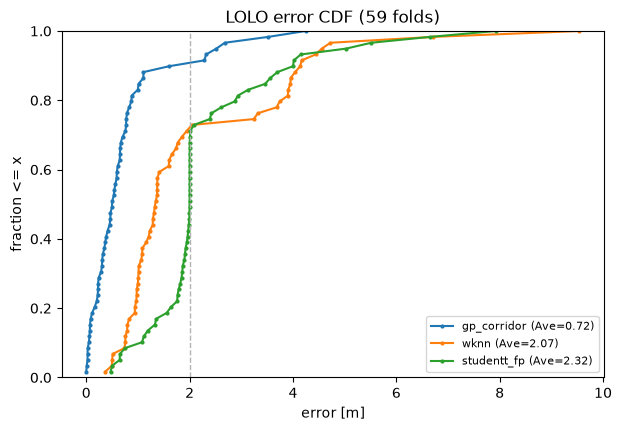

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for m in sorted(METHODS, key=lambda m: lolo_sum.set_index("method").loc[m, "ave"]):
    e = np.sort(lolo_led.loc[lolo_led["method"] == m, "error"].dropna().to_numpy())
    y = np.arange(1, len(e)+1) / len(e)
    ax.plot(e, y, marker=".", ms=4, label=f"{m} (Ave={lolo_sum.set_index('method').loc[m,'ave']:.2f})")
ax.axvline(2.0, color="0.7", ls="--", lw=1)
ax.set_xlabel("error [m]"); ax.set_ylabel("fraction <= x"); ax.set_ylim(0, 1)
ax.set_title("LOLO error CDF (59 folds)"); ax.legend(fontsize=8); plt.show()

## 6. 診断値（選択ハイパーパラメータ）

各手法を FULL forward プール（59 地点全て）で fit した際の選択値。
`scripts/dump_method_diagnostics.py` が `results/method_diagnostics.csv` に書くのと同じ経路。

In [10]:
wk_d = REGISTRY["wknn"]().fit(scans_f, ap13, truth)
st_d = REGISTRY["studentt_fp"]().fit(scans_f, ap13, truth)
gp_d = REGISTRY["gp_corridor"]().fit(scans_f, ap13, truth)
gp_d.predict(scans_f)  # fallback_count を得るための自己予測（診断専用）
n_total_keys = ap_band_fingerprint(scans_f).groupby(["ap_name", "band"]).ngroups

diag = pd.DataFrame([
    {"method": "wknn",        "key": "selected_k",             "value": wk_d.selected_k},
    {"method": "wknn",        "key": "selected_weighting",     "value": wk_d.selected_weighting},
    {"method": "studentt_fp", "key": "selected_nu",            "value": st_d.selected_nu},
    {"method": "gp_corridor", "key": "segment_train_accuracy", "value": gp_d.segment_train_accuracy},
    {"method": "gp_corridor", "key": "n_gp_keys",              "value": len(gp_d.gp_params)},
    {"method": "gp_corridor", "key": "n_total_keys",           "value": n_total_keys},
    {"method": "gp_corridor", "key": "fallback_count",         "value": gp_d.fallback_count},
])
diag

,method,key,value
0,wknn,selected_k,5
1,wknn,selected_weighting,inv_sq
2,studentt_fp,selected_nu,3
3,gp_corridor,segment_train_accuracy,1.0
4,gp_corridor,n_gp_keys,82
5,gp_corridor,n_total_keys,102
6,gp_corridor,fallback_count,0


## 7. 照合セル（必須）

ノートで計算した指標を、凍結済み `results/protocol_a.csv`・`results/lolo_summary.csv` の
該当行と `np.testing.assert_allclose(atol=1e-6)` で照合する。

**照合列は per-method で完結する指標のみ**。`delta_vs_wcl` 系は基準手法 `wcl` を今回の
sweep に含めていないため NaN になるので除外する（これらは手法内部の指標ではない）。
`ci_lo/ci_hi` は `seed=0, B=1000` で決定的なので照合に含め、bootstrap 再現性も同時検証する。

In [11]:
frozen_pa = pd.read_csv(ROOT / "results" / "protocol_a.csv")
frozen_lolo = pd.read_csv(ROOT / "results" / "lolo_summary.csv")

pa_cols = ["ave", "median", "p75", "p90", "max", "std",
           "within_2m", "within_4m", "ci_lo", "ci_hi"]
lolo_cols = ["ave", "median", "p90", "within_2m"]

# --- Protocol A ---
for m in METHODS:
    for fold in ["forward_to_backward", "backward_to_forward"]:
        a = proto_res[(proto_res.method == m) & (proto_res.fold == fold)][pa_cols].to_numpy()[0]
        b = frozen_pa[(frozen_pa.method == m) & (frozen_pa.fold == fold)][pa_cols].to_numpy()[0]
        np.testing.assert_allclose(a, b, atol=1e-6)
print("Protocol A: 全", len(METHODS)*2, "行が凍結 CSV と一致")

# --- LOLO ---
for m in METHODS:
    a = lolo_sum[lolo_sum.method == m][lolo_cols].to_numpy()[0]
    b = frozen_lolo[frozen_lolo.method == m][lolo_cols].to_numpy()[0]
    np.testing.assert_allclose(a, b, atol=1e-6)
print("LOLO: 全", len(METHODS), "手法が凍結 CSV と一致")

print("\n>>> 照合結果: 一致 (assert_allclose atol=1e-6 を全てパス) <<<")

Protocol A: 全 6 行が凍結 CSV と一致
LOLO: 全 3 手法が凍結 CSV と一致

>>> 照合結果: 一致 (assert_allclose atol=1e-6 を全てパス) <<<


## 8. 実行環境と所要時間

In [12]:
import scipy, sklearn
print("=== 実行環境 ===")
print("Python  :", platform.python_version(), "/", platform.platform())
print("numpy   :", np.__version__)
print("pandas  :", pd.__version__)
print("scipy   :", scipy.__version__)
print("sklearn :", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("\n=== 重い計算セルの経過時間 ===")
for k, v in TIMINGS.items():
    print(f"  {k:<12}: {v:6.1f} s")
print(f"  {'合計':<12}: {sum(TIMINGS.values()):6.1f} s")

=== 実行環境 ===
Python  : 3.11.14 / macOS-27.0-arm64-arm-64bit
numpy   : 2.4.6
pandas  : 3.0.4
scipy   : 1.17.1
sklearn : 1.9.0
matplotlib: 3.11.0

=== 重い計算セルの経過時間 ===
  protocol_a  :    1.3 s
  lolo        :   30.6 s
  合計          :   31.9 s
